In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from tqdm import tqdm

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT, preprocess_and_save_original_dataset, get_split_indices
from src.train_gnn import evaluate_dataset

In [ ]:
DATASET_NAMES = [
        "AIDS", "BZR", "COX2", "DHFR", "Mutagenicity", "MUTAG", "NCI1", "NCI109",
        "PTC_FM", "PTC_FR", "PTC_MM", "PTC_MR", "PROTEINS", 

        # Originally with more than 2 classes, but can be binarized
        "ENZYMES", "Cuneiform", "MSRC_9", "MSRC_21", "MSRC_21C"
    ]
DATA_DIR = PROJECT_ROOT / "data"

def generate_paired_datasets(dataset_names: list[str], cut_number: int) -> None:
    """Generates two versions of datasets (log_bin_deg and constant features) with the exact same sampled graphs."""
    if DATA_DIR.exists():
        raise FileExistsError(f"La cartella {DATA_DIR} esiste già! Rimuovila per procedere con la generazione di nuovi campionamenti, altrimenti interrompo l'esecuzione.")
        
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    
    for dname in dataset_names:
        # Usa un seed fisso in modo che sample_dataset campioni esattamente gli stessi grafi in entrambi i casi
        rng_1 = np.random.default_rng(42)
        preprocess_and_save_original_dataset(
            dataset_name=dname,
            data_dir=DATA_DIR,
            max_size=cut_number,
            rng=rng_1,
            feature_type="log_bin_deg",
            out_filename=f"{dname}_log_bin_deg.pt"
        )
        
        rng_2 = np.random.default_rng(42)
        preprocess_and_save_original_dataset(
            dataset_name=dname,
            data_dir=DATA_DIR,
            max_size=cut_number,
            rng=rng_2,
            feature_type="random_sample",
            out_filename=f"{dname}_original.pt"
        )

generate_paired_datasets(DATASET_NAMES, cut_number=15000)

def load_graph_stats() -> pd.DataFrame:
    """Loads dataset of graph statistics for each graph in the original datasets."""
    rows = []
    
    for dname in tqdm(DATASET_NAMES, desc="Loading datasets"):
        pt_path = DATA_DIR / dname / f"{dname}_original.pt"
        if not pt_path.exists():
            print(f"Skipping {dname}, file not found: {pt_path}")
            continue
            
        dataset = DatasetPT(pt_path)
        metadata = dataset.metadata
        pgs_list = metadata.get("per_graph_statistics", [])
        
        for i in range(len(dataset)):
            data = dataset[i]
            label = int(data.y.item()) if data.y is not None else None
            
            stats = pgs_list[i] if i < len(pgs_list) else {}
            
            dm = stats.get("degree_moments")
            dm = dm if dm is not None else [None] * 4
            annd = stats.get("annd")
            annd = annd if annd is not None else [None] * 4
            ecc = stats.get("eccentricity")
            ecc = ecc if ecc is not None else [None] * 4
            motifs = stats.get("motifs")
            motifs = motifs if motifs is not None else [None] * 8
            
            row = {
                "dataset": dname,
                "graph_idx": i,
                "label": label,
                
                # explicit topological stats
                "n_nodes": stats.get("n_nodes"),
                "n_edges": stats.get("n_edges"),
                "degree_moment_1": dm[0],
                "degree_moment_2": dm[1],
                "degree_moment_3": dm[2],
                "degree_moment_4": dm[3],
                "annd_1": annd[0],
                "annd_2": annd[1],
                "annd_3": annd[2],
                "annd_4": annd[3],
                "eccentricity_1": ecc[0],
                "eccentricity_2": ecc[1],
                "eccentricity_3": ecc[2],
                "eccentricity_4": ecc[3],
                "motif_0": motifs[0],
                "motif_1": motifs[1],
                "motif_2": motifs[2],
                "motif_3": motifs[3],
                "motif_4": motifs[4],
                "motif_5": motifs[5],
                "motif_6": motifs[6],
                "motif_7": motifs[7],
                
                # Implicit topological stats
                "modularity": stats.get("modularity"),
                "clustering": stats.get("clustering"),
                "assortativity": stats.get("assortativity"),
                "efficiency": stats.get("efficiency"),
                "diameter": stats.get("diameter"),
            }
            rows.append(row)
            
    return pd.DataFrame(rows)

df_stats = load_graph_stats()
display(df_stats.head())

Processing...
Done!
Analyzing graph statistics: 100%|██████████| 2000/2000 [00:02<00:00, 923.48it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 405/405 [00:00<00:00, 833.27it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 467/467 [00:00<00:00, 800.48it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 756/756 [00:00<00:00, 772.28it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 4337/4337 [00:05<00:00, 840.79it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 188/188 [00:00<00:00, 879.11it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 4110/4110 [00:04<00:00, 836.18it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 4127/4127 [00:05<00:00, 818.71it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 349/349 [00:00<00:00, 957.35it/s]
Processing...
Done!
Analyzing graph statistics: 100%|██████████| 351/351 [00:00<00:00, 915.24it/s]
Pr

,dataset,graph_idx,label,n_nodes,n_edges,degree_moment_1,degree_moment_2,degree_moment_3,degree_moment_4,annd_1,...,motif_3,motif_4,motif_5,motif_6,motif_7,modularity,clustering,assortativity,efficiency,diameter
0,AIDS,0,0,47,53,0.049029,0.000512,2.767572e-01,1.882203,0.076087,...,0.000796,0.0,0.0,0.0,0.0,0.673015,0.0,-0.338384,0.234643,14.0
1,AIDS,1,1,11,11,0.200000,0.010909,5.578656e-01,1.888889,0.333333,...,0.060606,0.0,0.0,0.0,0.0,0.380165,0.0,-0.534884,0.501212,5.0
2,AIDS,2,1,9,8,0.222222,0.006173,2.544643e-01,2.959821,0.250000,...,0.063492,0.0,0.0,0.0,0.0,0.414062,0.0,0.000000,0.482870,6.0
3,AIDS,3,1,10,10,0.222222,0.009877,-9.169214e-16,0.870536,0.333333,...,0.076190,0.0,0.0,0.0,0.0,0.340000,0.0,-0.562500,0.517407,5.0
4,AIDS,4,0,16,17,0.141667,0.002708,-2.453434e-01,1.631901,0.183333,...,0.017033,0.0,0.0,0.0,0.0,0.442907,0.0,-0.355072,0.397523,9.0


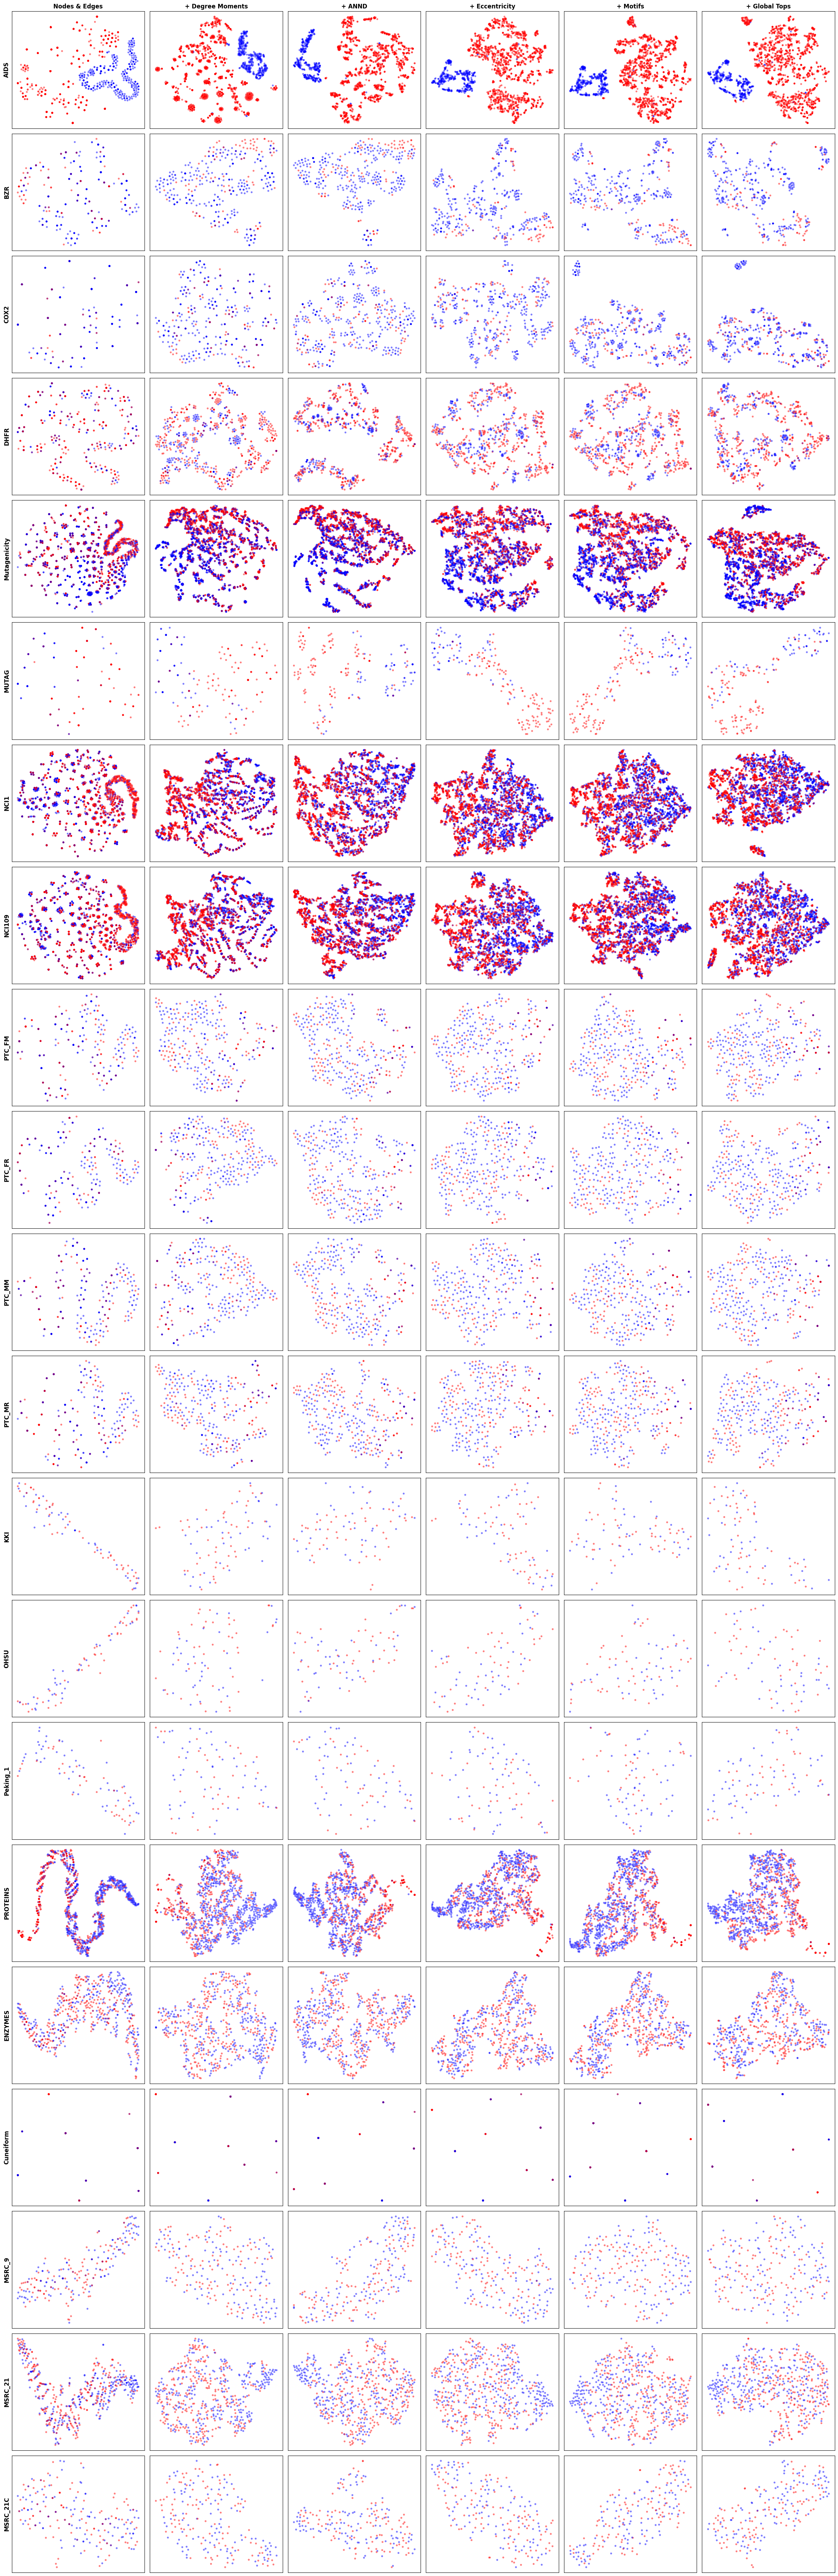

In [5]:
def plot_improving_distinctions(df: pd.DataFrame, datasets: list[str], method: str = "pca") -> None:
    """Plots PCA or t-SNE projections of per-graph statistics for selected datasets."""
    n_rows = len(datasets)
    n_cols = 6
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), squeeze=False)
    
    # Define feature sets
    feat_1 = ["n_nodes", "n_edges"]
    feat_2 = feat_1 + ["degree_moment_1", "degree_moment_2", "degree_moment_3", "degree_moment_4"]
    feat_3 = feat_2 + ["annd_1", "annd_2", "annd_3", "annd_4"]
    feat_4 = feat_3 + ["eccentricity_1", "eccentricity_2", "eccentricity_3", "eccentricity_4"]
    feat_5 = feat_4 + ["motif_0", "motif_1", "motif_2", "motif_3", "motif_4", "motif_5", "motif_6", "motif_7"]
    feat_6 = feat_5 + ["modularity", "clustering", "assortativity", "efficiency", "diameter"]
    
    feature_sets = [feat_1, feat_2, feat_3, feat_4, feat_5, feat_6]
    titles = [
        "Nodes & Edges",
        "+ Degree Moments",
        "+ ANND",
        "+ Eccentricity",
        "+ Motifs",
        "+ Global Tops"
    ]
    
    for r_idx, dname in enumerate(datasets):
        df_ds = df[df["dataset"] == dname].copy()
        
        # Drop rows with NaNs in the required columns for PCA
        all_feats = feature_sets[-1]
        df_ds = df_ds.dropna(subset=all_feats + ["label"])
        
        if len(df_ds) == 0:
            for c_idx in range(n_cols):
                axes[r_idx, c_idx].set_title(f"{dname} - No Data")
                axes[r_idx, c_idx].axis("off")
            continue
            
        labels = df_ds["label"].values
        # Class 0: blue, Class 1: red
        colors = np.where(labels == 0, "blue", "red")
        
        for c_idx, feats in enumerate(feature_sets):
            ax = axes[r_idx, c_idx]
            
            X = df_ds[feats].values
            X_scaled = StandardScaler().fit_transform(X)
            
            n_comp = min(2, X_scaled.shape[1])
            
            if method.lower() == "pca":
                reducer = PCA(n_components=n_comp)
                X_reduced = reducer.fit_transform(X_scaled)
            elif method.lower() == "tsne":
                # t-SNE typically maps to 2 components. Since all our feature sets 
                # have at least 2 features (n_nodes, n_edges), we can use n_components=2
                n_comp = 2
                reducer = TSNE(n_components=n_comp, random_state=42)
                X_reduced = reducer.fit_transform(X_scaled)
            else:
                raise ValueError("Method must be 'pca' or 'tsne'")
            
            # If n_comp is 1, pad with zeros for y-axis
            if n_comp == 1:
                x_coords = X_reduced[:, 0]
                y_coords = np.zeros_like(x_coords)
            else:
                x_coords = X_reduced[:, 0]
                y_coords = X_reduced[:, 1]
                
            ax.scatter(x_coords, y_coords, c=colors, alpha=0.5, s=15, edgecolors='none')
            
            if r_idx == 0:
                ax.set_title(titles[c_idx], fontsize=12, fontweight="bold")
            if c_idx == 0:
                ax.set_ylabel(dname, fontsize=12, fontweight="bold")
                
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.tight_layout()
    plt.show()

plot_improving_distinctions(df_stats, DATASET_NAMES, method="tsne")

In [6]:
def evaluate_gnn_performances(dataset_names: list[str], runs: int = 5) -> pd.DataFrame:
    """Evaluates GCN and GIN on original and log_bin_deg features, averaging over runs."""
    all_results = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    for dname in tqdm(dataset_names, desc="Evaluating datasets"):
        for feat_type in ["original", "log_bin_deg"]:
            pt_path = DATA_DIR / dname / f"{dname}_{feat_type}.pt"
            if not pt_path.exists():
                print(f"Warning: {pt_path} not found. Skipping.")
                continue
            
            dataset_obj = DatasetPT(pt_path)
            data_list = [dataset_obj[i] for i in range(len(dataset_obj))]
            split_indices = get_split_indices(data_list, seed=42)
            
            gnn_config = {
                "num_runs"  : runs,
                "lr"        : 5e-4,
                "hidden_dim": 256,
                "num_layers": 3,
                "dropout"   : 0.1,
                "epochs"    : 50,
                "batch_size": 16,
                "in_dim"     : dataset_obj.metadata.get("in_dim", 1),
                "num_classes": dataset_obj.metadata.get("num_classes", 2),
            }
            
            # Run evaluations
            glob_res, _ = evaluate_dataset(
                pt_path=pt_path,
                gnn_config=gnn_config,
                device=device,
                split_indices=split_indices,
                dataset_name=dname
            )
            
            # Adjust the source name slightly to distinguish them in the summary
            for res in glob_res:
                res["source"] = feat_type
                
            all_results.extend(glob_res)
            
    df_res = pd.DataFrame(all_results)
    if len(df_res) == 0:
        return df_res
        
    # Group by dataset, source (feature type), and model to compute mean of test_f1
    summary_df = df_res.groupby(["dataset", "source", "model"], as_index=False)[["test_f1"]].mean()
    
    # Pivot to have one row per dataset
    summary_df = summary_df.pivot(index="dataset", columns=["model", "source"], values="test_f1")
    summary_df.columns = [f"{model}_{source}" for model, source in summary_df.columns]
    summary_df = summary_df.reset_index()
    
    display(summary_df)
    return summary_df

df_gnn_perf = evaluate_gnn_performances(DATASET_NAMES, runs=5)

Evaluating datasets: 100%|██████████| 21/21 [1:43:08<00:00, 294.69s/it]  


,dataset,GCN_log_bin_deg,GIN_log_bin_deg,GCN_original,GIN_original
0,AIDS,0.981062,0.977111,0.968443,0.973303
1,BZR,0.668777,0.733795,0.717852,0.766060
2,COX2,0.668592,0.592716,0.623564,0.602597
3,Cuneiform,0.604465,0.605358,0.834634,0.836506
4,DHFR,0.765621,0.783620,0.797440,0.789742
5,ENZYMES,0.509397,0.531347,0.646938,0.660553
6,KKI,0.455706,0.585924,0.462777,0.430831
7,MSRC_21,0.594002,0.545138,0.920339,0.925645
8,MSRC_21C,0.502501,0.524748,0.923663,0.957015
9,MSRC_9,0.494915,0.414207,0.906095,0.919974
